# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc134a"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.45 0.49777777777777776 0.5455555555555556 ... 1.55 1.65 1.65] [0.45 0.49777777777777776 0.5239393939393939 ... 1.499047619047619 1.65 1.65] [0.45 0.486969696969697 0.62 ... 1.499047619047619 1.65 1.65] [0.45 0.5475862068965517 0.6451724137931034 ... 1.499047619047619 1.65 1.65] [0.45 0.49777777777777776 0.5704597701149425 ... 1.499047619047619 1.65 1.65] [0.45 0.4977777777777778 0.5455555555555555 ... 1.499047619047619 1.65 1.65]] [[0.66 0.6766666666666666 0.6933333333333334 ... 1.7106666666666666 1.903333333333333 1.88] [0.66 0.6766666666666666 0.729090909090909 ... 1.7666666666666668 1.8233333333333333 1.88] [0.66 0.6945454545454546 0.8150000000000001 ... 1.5875 1.7525925925925925 1.88] [0.66 0.76 0.86 ... 1.6251851851851853 1.7902777777777774 1.88] [0.66 0.6766666666666666 0.735 ... 1.6628703703703704 1.8279629629629628 1.88] [0.66 0.6766666666666666 0.6933333333333334 ... 1.7005555555555554 1.865648148148148 1.88]] [[0.65 0.7088888888888889 0.7677777777777779 ... 1.8783333333333332 2.085 1.93] [0.65 0.7088888888888889 0.7833333333333333 ... 1.94 1.935 1.93] [0.65 0.7166666666666667 0.8510714285714287 ... 1.6541666666666666 1.8246296296296296 1.93] [0.65 0.7837878787878787 0.9175757575757575 ... 1.7192592592592593 1.8897222222222223 1.93] [0.65 0.7088888888888889 0.8052272727272728 ... 1.7843518518518517 1.9548148148148148 1.93] [0.65 0.7088888888888889 0.7677777777777778 ... 1.8494444444444444 2.0199074074074073 1.93]] ... [[129.52499999999998 129.5633333333333 129.60166666666666 ... 142.99666666666667 141.82 141.915] [129.52499999999998 129.5633333333333 129.7331818181818 ... 147.68 144.7975 141.915] [129.52499999999998 129.6290909090909 131.12544642857142 ... 141.555 141.74444444444444 141.915] [129.52499999999998 130.67619047619044 131.82738095238093 ... 141.1725925925926 141.76333333333335 141.915] [129.52499999999998 129.5633333333333 130.15809523809523 ... 140.79018518518518 141.78222222222223 141.915] [129.52499999999998 129.56333333333333 129.60166666666663 ... 140.40777777777777 141.8011111111111 141.915]] [[130.25 130.0641666666667 129.87833333333336 ... 144.80625 143.9225 142.385] [130.25 130.06416666666667 131.12594736842107 ... 155.33666666666667 148.86083333333335 142.385] [130.25 130.68797368421053 132.99736842105264 ... 142.52 142.6158333333333 142.385] [130.25 131.3920238095238 132.5340476190476 ... 142.3565740740741 142.94250000000002 142.385] [130.25 130.06416666666667 130.5422619047619 ... 142.19314814814817 143.26916666666668 142.385] [130.25 130.06416666666667 129.87833333333333 ... 142.02972222222223 143.59583333333333 142.385]] [[130.245 130.2975 130.35000000000002 ... 145.37566666666666 143.948 143.626] [130.245 130.29749999999999 131.47254385964914 ... 143.73 143.678 143.626] [130.245 130.85877192982457 133.1563596491228 ... 144.55 144.07244444444444 143.626] [130.245 131.61488095238096 132.9847619047619 ... 143.89224074074076 144.04133333333334 143.626] [130.245 130.2975 131.00869047619048 ... 143.2344814814815 144.01022222222224 143.626] [130.245 130.2975 130.35 ... 142.57672222222223 143.9791111111111 143.626]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.45 0.49777777777777776 0.5455555555555556 ... 1.55 1.65 1.65] [0.45 0.49777777777777776 0.5239393939393939 ... 1.499047619047619 1.65 1.65] [0.45 0.486969696969697 0.62 ... 1.499047619047619 1.65 1.65] [0.45 0.5475862068965517 0.6451724137931034 ... 1.499047619047619 1.65 1.65] [0.45 0.49777777777777776 0.5704597701149425 ... 1.499047619047619 1.65 1.65] [0.45 0.4977777777777778 0.5455555555555555 ... 1.499047619047619 1.65 1.65]] [[0.66 0.6766666666666666 0.6933333333333334 ... 1.7106666666666666 1.903333333333333 1.88] [0.66 0.6766666666666666 0.729090909090909 ... 1.7666666666666668 1.8233333333333333 1.88] [0.66 0.6945454545454546 0.8150000000000001 ... 1.5875 1.7525925925925925 1.88] [0.66 0.76 0.86 ... 1.6251851851851853 1.7902777777777774 1.88] [0.66 0.6766666666666666 0.735 ... 1.6628703703703704 1.8279629629629628 1.88] [0.66 0.6766666666666666 0.6933333333333334 ... 1.7005555555555554 1.865648148148148 1.88]] [[0.65 0.7088888888888889 0.7677777777777779 ... 1.8783333333333332 2.085 1.93] [0.65 0.7088888888888889 0.7833333333333333 ... 1.94 1.935 1.93] [0.65 0.7166666666666667 0.8510714285714287 ... 1.6541666666666666 1.8246296296296296 1.93] [0.65 0.7837878787878787 0.9175757575757575 ... 1.7192592592592593 1.8897222222222223 1.93] [0.65 0.7088888888888889 0.8052272727272728 ... 1.7843518518518517 1.9548148148148148 1.93] [0.65 0.7088888888888889 0.7677777777777778 ... 1.8494444444444444 2.0199074074074073 1.93]] ... [[129.52499999999998 129.5633333333333 129.60166666666666 ... 142.99666666666667 141.82 141.915] [129.52499999999998 129.5633333333333 129.7331818181818 ... 147.68 144.7975 141.915] [129.52499999999998 129.6290909090909 131.12544642857142 ... 141.555 141.74444444444444 141.915] [129.52499999999998 130.67619047619044 131.82738095238093 ... 141.1725925925926 141.76333333333335 141.915] [129.52499999999998 129.5633333333333 130.15809523809523 ... 140.79018518518518 141.78222222222223 141.915] [129.52499999999998 129.56333333333333 129.60166666666663 ... 140.40777777777777 141.8011111111111 141.915]] [[130.25 130.0641666666667 129.87833333333336 ... 144.80625 143.9225 142.385] [130.25 130.06416666666667 131.12594736842107 ... 155.33666666666667 148.86083333333335 142.385] [130.25 130.68797368421053 132.99736842105264 ... 142.52 142.6158333333333 142.385] [130.25 131.3920238095238 132.5340476190476 ... 142.3565740740741 142.94250000000002 142.385] [130.25 130.06416666666667 130.5422619047619 ... 142.19314814814817 143.26916666666668 142.385] [130.25 130.06416666666667 129.87833333333333 ... 142.02972222222223 143.59583333333333 142.385]] [[130.245 130.2975 130.35000000000002 ... 145.37566666666666 143.948 143.626] [130.245 130.29749999999999 131.47254385964914 ... 143.73 143.678 143.626] [130.245 130.85877192982457 133.1563596491228 ... 144.55 144.07244444444444 143.626] [130.245 131.61488095238096 132.9847619047619 ... 143.89224074074076 144.04133333333334 143.626] [130.245 130.2975 131.00869047619048 ... 143.2344814814815 144.01022222222224 143.626] [130.245 130.2975 130.35 ... 142.57672222222223 143.9791111111111 143.626]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc134a' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[  4.85         5.06         5.195      ...   6.4
      6.69         6.58      ]
   [  7.02         7.3          7.48       ...   9.15
      9.44         9.585     ]
   [  9.835       10.19        10.28       ...  12.49
     12.63666667  12.985     ]
   ...
   [109.39666667 109.78       110.43666667 ... 114.78
    115.30666667 115.31      ]
   [115.3675     115.3875     115.72666667 ... 120.355
    120.50333333 120.48      ]
   [120.33       120.63       120.97333333 ... 124.77
    124.90333333 125.53      ]]

  [[  4.85         4.93281667   5.09005    ...   6.59135
      6.7373       6.8567    ]
   [  7.1425       7.16185      7.596575   ...   9.28315
      9.55773333   9.7622    ]
   [  9.927       10.18905     10.50095    ...  12.567775
     12.77323333  12.88185   ]
...
   [124.12766667 124.06841667 124.27408333 ... 128.7245
    129.87558333 130.39441667]
   [130.77866667 130.8605     130.20791667 ... 133.49583333
    134.6925     135.31333333]
   [135.12675    134.86533333 135.40388889 ... 138.75725
    139.86513889 140.76616667]]

  [[  8.62         9.11666667   8.71       ...  10.81
     11.31333333  11.98666667]
   [ 12.44        12.275       12.08       ...  14.3
     14.89        15.37      ]
   [ 15.4875      15.51666667  15.72666667 ...  18.27
     18.42333333  19.1       ]
   ...
   [123.7785     124.2555     124.2935     ... 128.268
    129.39925    130.35      ]
   [130.65625    130.3955     130.049      ... 133.05825
    134.34216667 134.72      ]
   [135.01275    134.95675    135.0525     ... 138.06733333
    139.4795     140.70483333]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 4.932816666666667 5.09005 ... 125.2333 125.48676666666667 125.57709999999999] [4.72 4.934083333333334 5.105250000000001 ... 125.34649999999999 125.68549999999999 125.6455] ... [8.205 8.749444444444444 8.301944444444446 ... 139.91933333333333 140.02841666666666 140.909] [8.5375 9.116666666666667 8.6125 ... 138.332 139.48333333333335 140.58999999999995] [8.620000000000001 9.116666666666667 8.71 ... 137.92700000000002 139.40375 140.64575000000002]] [[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 4.890000000000001 5.05 ... 125.35 125.615 125.56999999999998] [6.8357142857142845 5.4592857142857145 5.502142857142857 ... 128.65178571428572 128.07892857142858 128.37720238095238] ... [8.55 8.94 8.38 ... 143.375 142.655 142.625] [8.585 9.116666666666667 8.545 ... 140.58083333333332 140.9915 141.60583333333335] [8.620000000000001 9.116666666666667 8.71 ... 137.78666666666666 139.328 140.58666666666667]] [[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 5.2596428571428575 5.348571428571429 ... 125.87305882352942 126.10698039215687 126.55990909090907] [5.77785714285714 5.8289285714285715 5.800714285714285 ... 127.49917647058822 127.80260784313725 128.57972727272727] ... [7.612500000000001 8.854651960784313 7.822625 ... 138.882 139.672 142.125] [8.163055555555555 9.116666666666667 8.30477777777778 ... 138.57 139.70999999999998 140.815] [8.620000000000001 9.116666666666667 8.71 ... 138.06733333333335 139.4795 140.70483333333334]] [[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 5.376513888888889 5.4664090909090906 ... 126.679125 126.91466666666669 127.33962500000001] [4.719999999999999 5.693027777777777 5.737818181818182 ... 128.58825000000002 128.92600000000002 129.14925] ... [7.706111111111111 8.769303921568628 7.899555555555556 ... 140.8675 141.62650000000002 141.414] [8.256666666666668 9.116666666666667 8.381708333333334 ... 139.60775 140.62875000000003 141.11849999999998] [8.620000000000001 9.116666666666667 8.71 ... 138.348 139.631 140.823]] [[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 5.0184500000000005 5.1701500000000005 ... 124.9999 125.23030000000001 125.5913] [4.72 5.177340277777778 5.3134545454545465 ... 126.01106250000001 126.33533333333334 126.53031250000001] ... [7.799722222222223 8.683955882352942 7.976486111111112 ... 140.55144444444443 141.09380555555555 141.24566666666664] [8.350277777777777 9.116666666666667 8.45863888888889 ... 139.1825 140.24694444444447 140.94233333333332] [8.620000000000001 9.116666666666667 8.71 ... 138.20766666666668 139.55525 140.76391666666666]] [[4.85 5.0600000000000005 5.195 ... 124.77 124.90333333333336 125.53] [4.85 4.9756333333333345 5.1301000000000005 ... 125.11659999999999 125.35853333333336 125.5842] [4.72 4.9769 5.145300000000001 ... 125.2298 125.55726666666666 125.6526] ... [7.8933333333333335 8.598607843137254 8.053416666666667 ... 140.23538888888888 140.56111111111113 141.0773333333333] [8.443888888888889 9.116666666666667 8.535569444444446 ... 138.75725 139.8651388888889 140.76616666666663] [8.620000000000001 9.116666666666667 8.71 ... 138.06733333333335 139.4795 140.70483333333334]]]
Units,ppt


### Longitudinal-mean

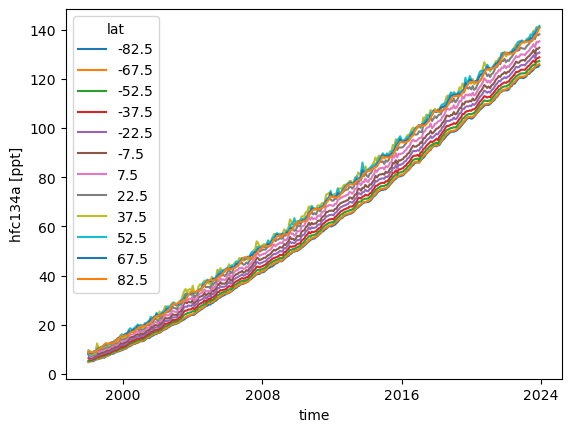

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

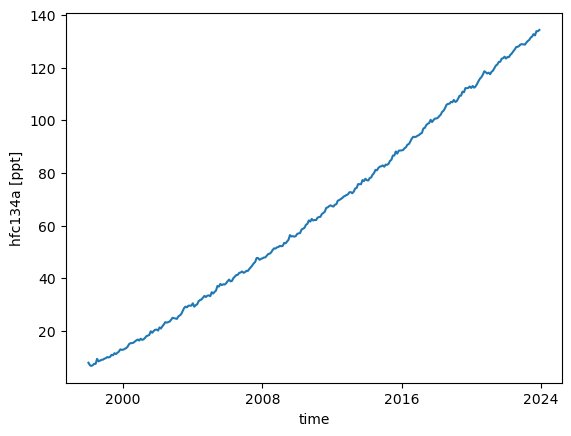

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

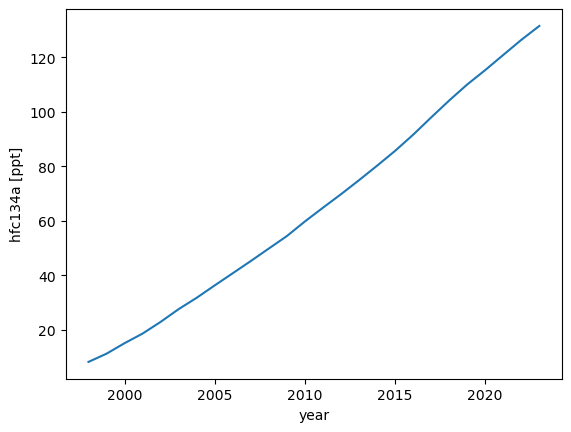

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4429 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -5.211 ... -7.874e-15

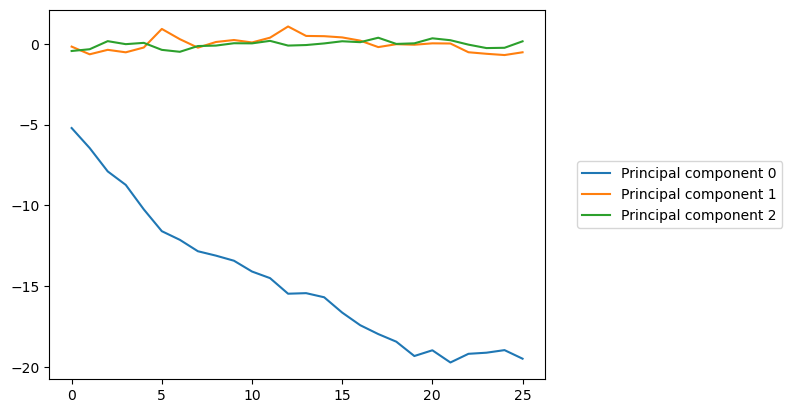

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

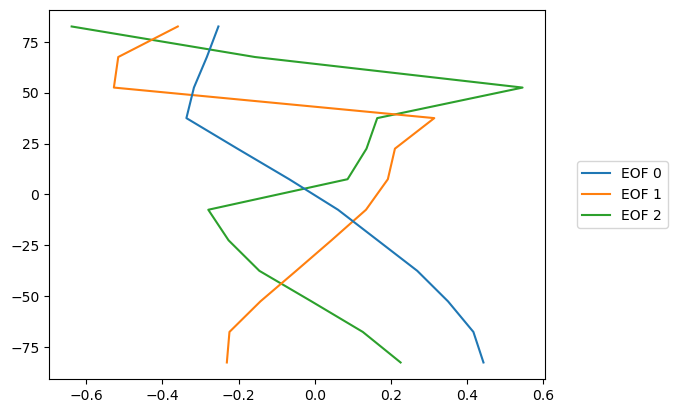

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

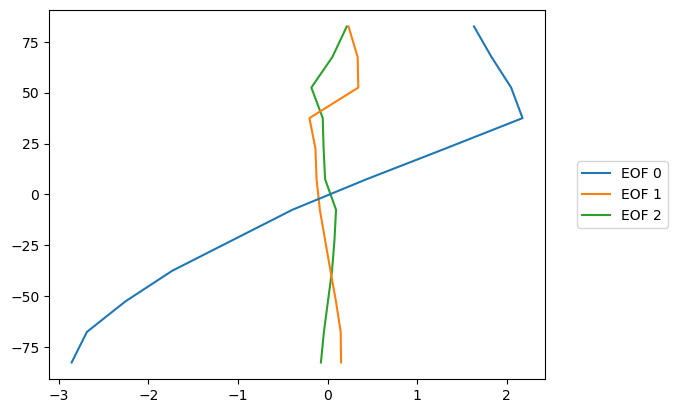

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.44289031225689185] [0.4164760865885307] [0.3498928848877422] [0.26909242868007965] [0.16508450616437953] [0.060970242133896464] [-0.06734967714082014] [-0.20317056276150766] [-0.3371163162337783] [-0.31737125487142925] [-0.2834441034469916] [-0.25310683413751295]]
Units,ppt
Magnitude,[[-5.211415589426403] [-6.450136252304118] [-7.895356174664178] [-8.730374188313712] [-10.24565628973375] [-11.59591484160542] [-12.131732298217168] [-12.837307500114996] [-13.109041133480755] [-13.42483663429198] [-14.092919003188447] [-14.501295894620904] [-15.466336758884117] [-15.431353522778885] [-15.686099509763636] [-16.634703906680052] [-17.415549822529893] [-17.963768588875684] [-18.43470330161187] [-19.322854135668145] [-18.9676567150265] [-19.722162669704666] [-19.186175101969827] [-19.117007166149946] [-18.95717933392641] [-19.48783251917948]]
Units,dimensionless


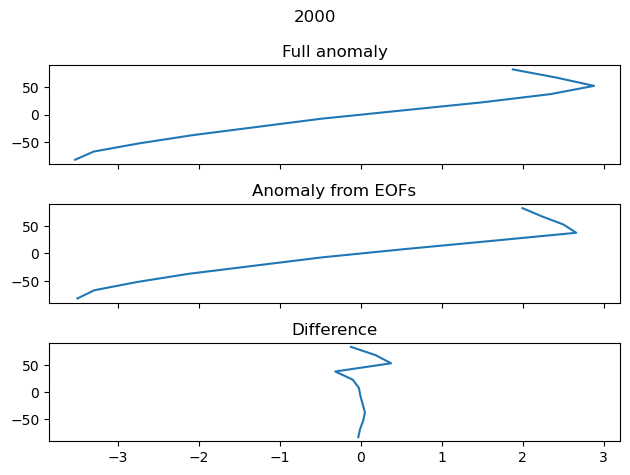

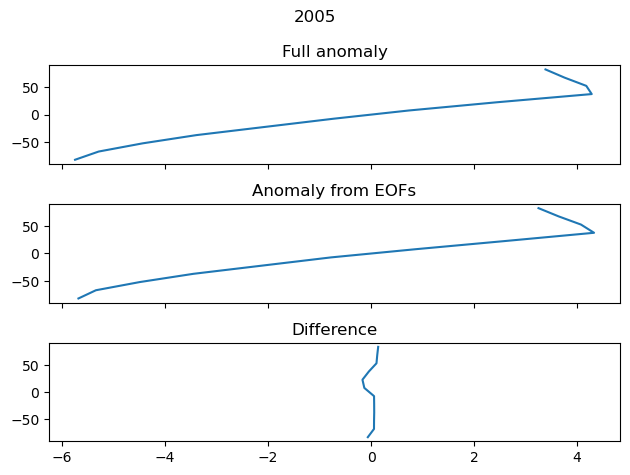

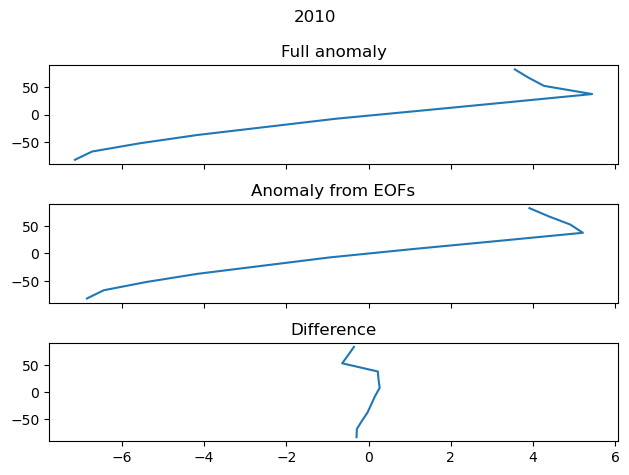

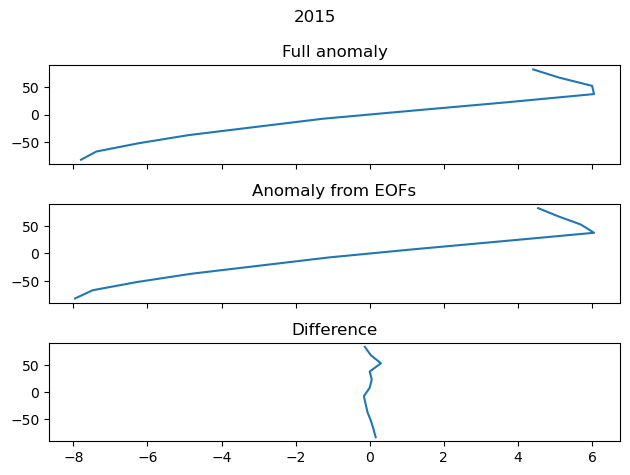

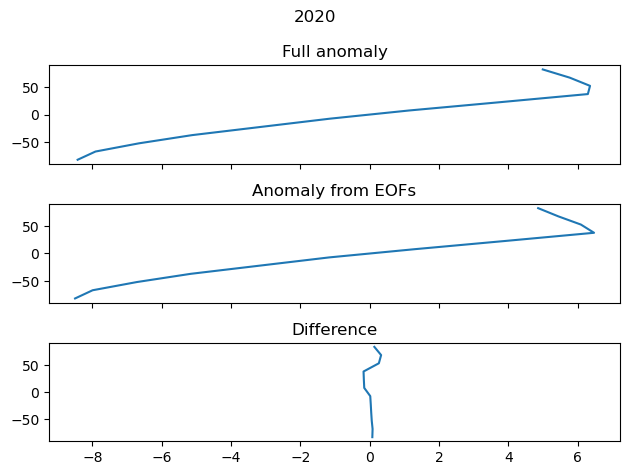

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 16359.83it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 18012.95it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 17635.24it/s]

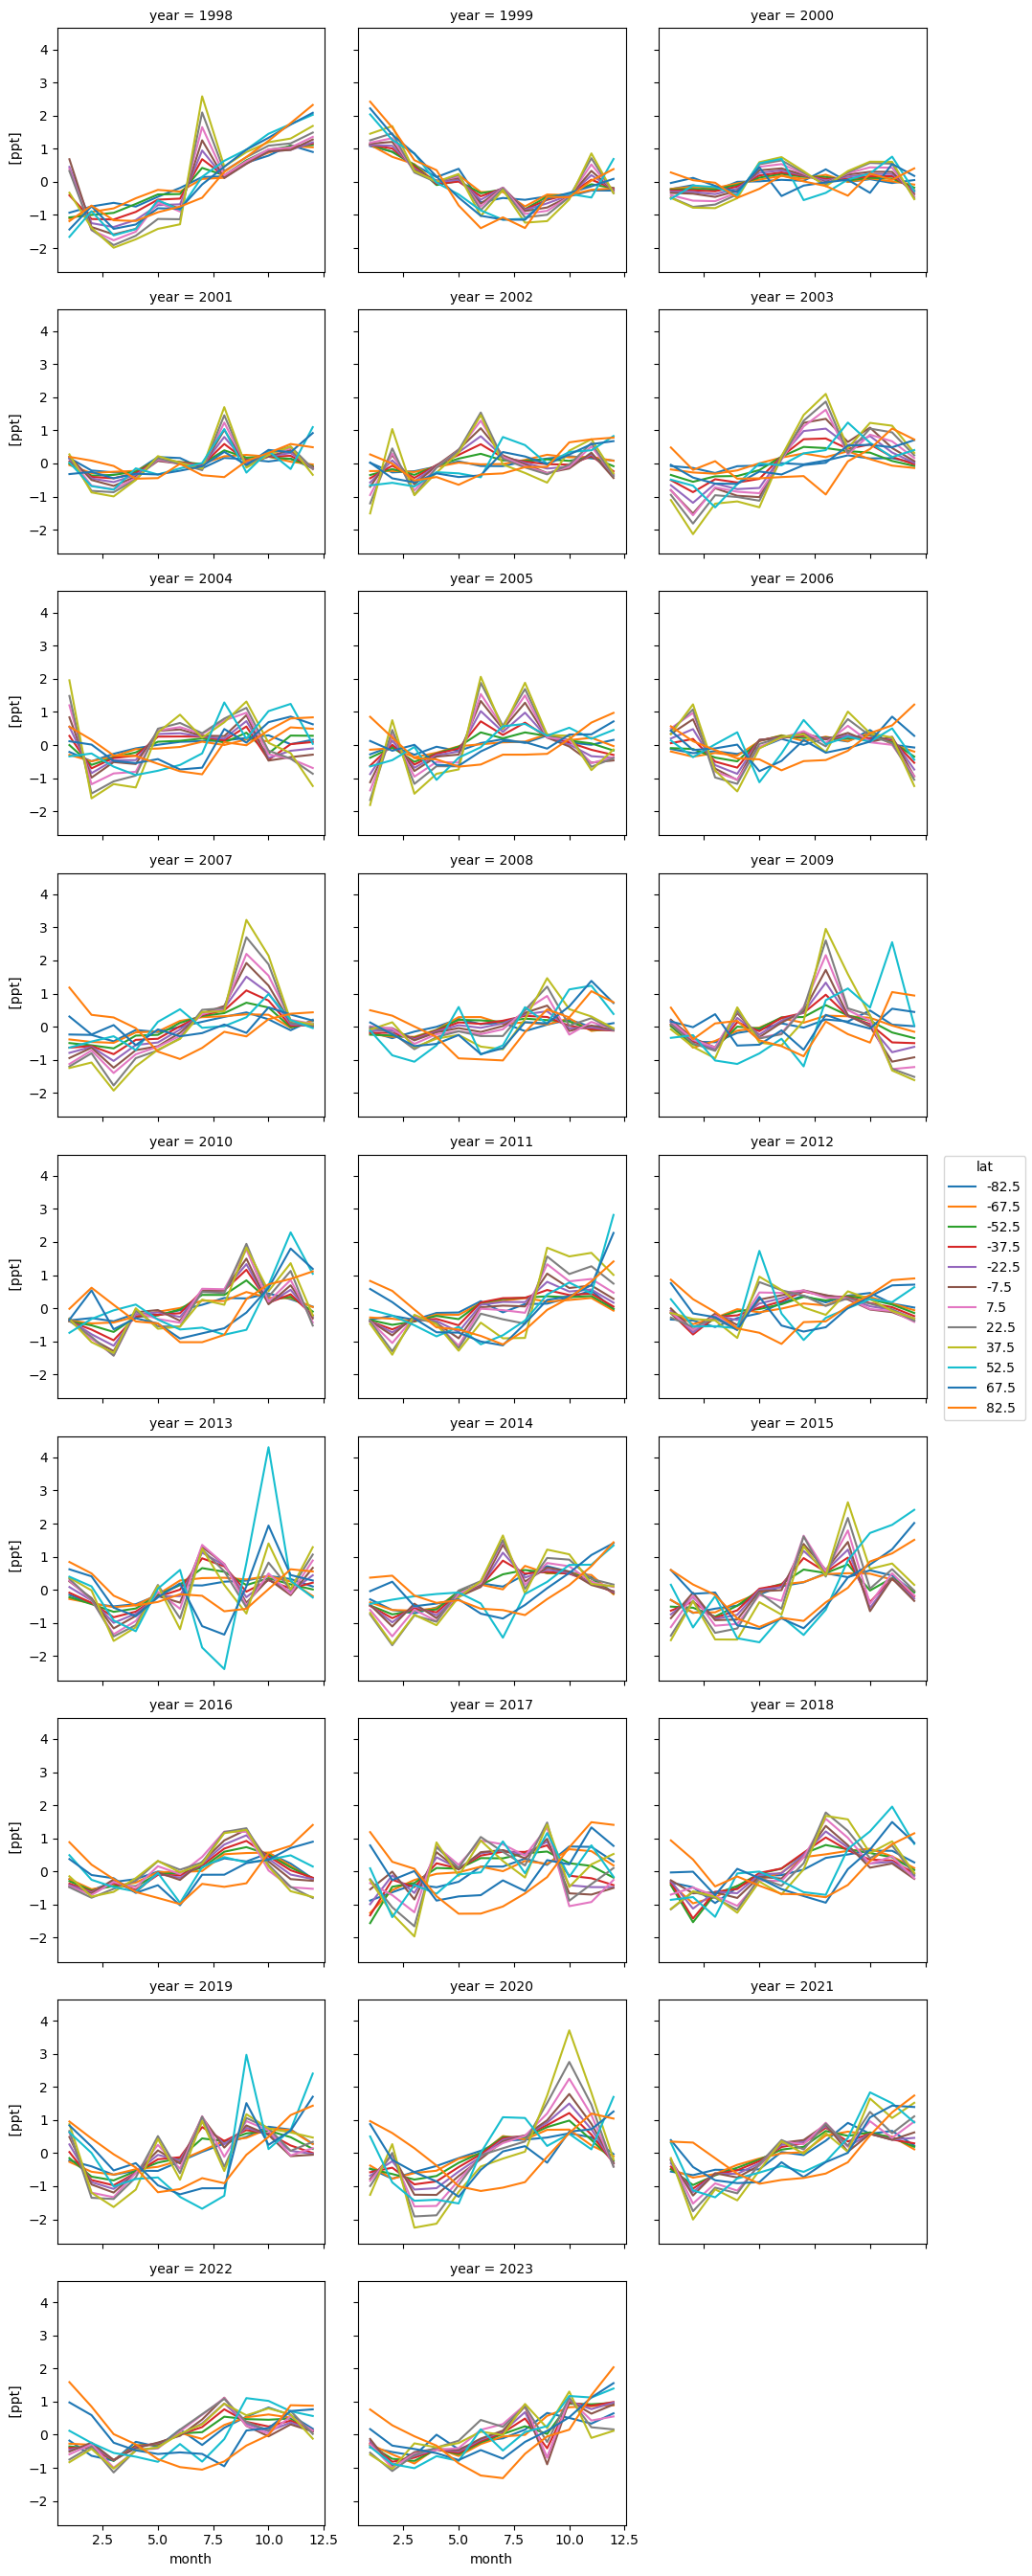

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

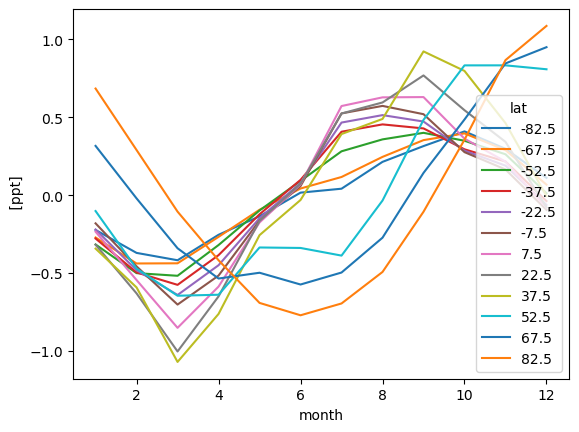

In [22]:
seasonality.plot.line(hue="lat")

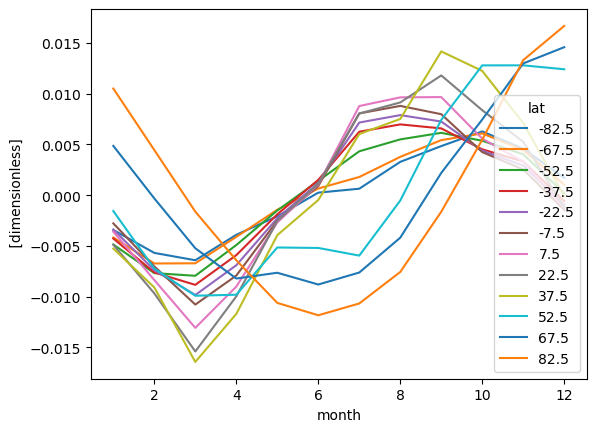

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[8.142021617112492 11.156538964140724 15.008482957367377 18.54134871255543 22.828394460644702 27.51526485470264 31.682741075640987 36.229987372383704 40.68682887374832 45.169985418904524 49.76049199504033 54.33765842627711 59.6926331035973 64.74117902581973 69.68630359545533 74.84187322496926 80.14957516532557 85.60420076226785 91.52338139418157 97.87329973320156 104.09306040311088 109.98280715198763 115.26744759227789 120.83177951709548 126.35603338771428 131.4733032989075]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.44289031225689185] [0.4164760865885307] [0.3498928848877422] [0.26909242868007965] [0.16508450616437953] [0.060970242133896464] [-0.06734967714082014] [-0.20317056276150766] [-0.3371163162337783] [-0.31737125487142925] [-0.2834441034469916] [-0.25310683413751295]]
Units,ppt
Magnitude,[[-5.211415589426403] [-6.450136252304118] [-7.895356174664178] [-8.730374188313712] [-10.24565628973375] [-11.59591484160542] [-12.131732298217168] [-12.837307500114996] [-13.109041133480755] [-13.42483663429198] [-14.092919003188447] [-14.501295894620904] [-15.466336758884117] [-15.431353522778885] [-15.686099509763636] [-16.634703906680052] [-17.415549822529893] [-17.963768588875684] [-18.43470330161187] [-19.322854135668145] [-18.9676567150265] [-19.722162669704666] [-19.186175101969827] [-19.117007166149946] [-18.95717933392641] [-19.48783251917948]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0034370527997038564 -0.00569786404257471 -0.006422930098863494 -0.003911963455264018 -0.002087096713855967 0.00024541469714460946 0.000633990568235307 0.003281311203539708 0.004837812243733988 0.006286067707019645 0.004568889342972075 0.0017033957316648165] [-0.004178381018199899 -0.006740633959894711 -0.006724377305230981 -0.0041165699305177935 -0.0014435416188886925 0.0006520222007992623 0.0017887760213966925 0.003772383714697756 0.005425240483706392 0.006090278143083068 0.004436985155175662 0.0010377978663855395] [-0.004868391921711075 -0.007693235356507659 -0.00795540648033982 -0.004922642891640961 -0.0015129785950880822 0.0014032388845868396 0.004323470584504113 0.005499330783045742 0.006145314692181017 0.005362839423147508 0.004029599897751842 0.00018884155739691828] [-0.00428083823015434 -0.007626640849528853 -0.008850418356920558 -0.005919542768600233 -0.0018887343960936086 0.0015028663323985736 0.006253379941476424 0.006977263978222144 0.006580508887968101 0.0045190426790036806 0.003314615616777591 -0.000581521787643287] [-0.003390816995306198 -0.007406577526030034 -0.009850284408423794 -0.006914711539996164 -0.002276399955156751 0.001199157023986724 0.0071588627811979355 0.007892446046861188 0.0072589521878793735 0.004386784305101434 0.0029087121373797624 -0.000966143817771764] [-0.0027842548221034356 -0.007028020003380028 -0.010795330377220929 -0.007935592840029348 -0.0025143970658440115 0.0008923441591172803 0.00806054905319799 0.008801445260346452 0.007984133767667536 0.004241224808505898 0.0025328613426238724 -0.0014549842386215885] [-0.0036099061623325853 -0.008374497912076478 -0.013089918243601506 -0.009020616597450416 -0.0026962991913137054 0.0010612008991614484 0.008788555968969295 0.009643873011549963 0.009671423676192796 0.005570714225640836 0.0033021441170352542 -0.0012467046853766092] [-0.0048936633516955255 -0.009692100040988477 -0.01541901732754523 -0.009987384547815299 -0.0025508052445473686 0.001125686539940144 0.00804997450867625 0.009141086033180932 0.011806275891394005 0.008375355475292504 0.005255941076324154 -0.0012113878720138326] [-0.005276585483464167 -0.009103611677984808 -0.016451593730821553 -0.011718398252992014 -0.003946695672309538 -0.00047979191733976624 0.006024783466350725 0.007513323088487013 0.01417491378874499 0.012250853077921967 0.007107616315207985 -9.485525793233452e-05] [-0.001568769223343778 -0.007251276658008119 -0.00992233081978396 -0.009824309051003132 -0.005163197054284862 -0.005210337423744436 -0.005964586841589309 -0.0005351228437056908 0.00742475508815302 0.012798473271584329 0.012801709273549951 0.012414963830911131] [0.004856385792212924 -0.00032218990594398076 -0.005239828943073732 -0.008226299600629322 -0.0076560981052139175 -0.008816001085580854 -0.0076339192280625075 -0.004198057893803799 0.0021912206083925232 0.007460696041039624 0.01299097656350436 0.01459308562624332] [0.010513489955823943 0.004448737526393342 -0.0016273666640513407 -0.006423010843732228 -0.01063052042847489 -0.01185123908646514 -0.010685571634412845 -0.00757789714591452 -0.0016397472032683637 0.005464835293717718 0.013318048009947667 0.016690212942190943]]
Units,dimensionless
